# Flow Matching classique vs Optimal Transport Flow Matching

Ce notebook complète `notebook.ipynb` (qui couvre le Flow Matching conditionnel "de base", CFM, avec
couplage indépendant $\pi = p_0 \otimes p_1$) en construisant, **dans le même notebook**, une comparaison
directe entre :

1. **Flow Matching classique (CFM)** : couplage indépendant entre bruit et données, chemin de
   probabilité conditionnel affine, régression $L^2$ sur la vitesse conditionnelle
   (Lipman *et al.*, 2023).
2. **Optimal Transport Flow Matching (OT-CFM)** : même perte de régression, mais les paires
   $(x_0, x_1)$ sont tirées, à chaque minibatch, selon le couplage de **transport optimal discret**
   (algorithme hongrois) plutôt qu'indépendamment (Tong *et al.*, 2023, *Improving and generalizing
   flow-based generative models with minibatch optimal transport*, arXiv:2302.00482).

On implémente les deux méthodes, on les entraîne **sur les deux mêmes jeux de données** :

- `make_moons` (2D, visualisable directement) ;
- MNIST (images $1\times28\times28$, U-Net).

puis on conclut par une **section de comparaison** : courbure des trajectoires, énergie cinétique,
qualité de génération en fonction du nombre de pas d'intégration (NFE), et qualité visuelle sur MNIST.

Les figures produites ici sont exportées dans `figures/` et intégrées au cours
`cours_flow_matching.tex`.

> Rappel théorique complet (équation de continuité, Benamou-Brenier, théorème de Brenier,
> théorème de marginalisation, théorème de régression) : voir `cours_flow_matching.pdf`,
> Sections 3 à 8. Ce notebook ne re-détaille que ce qui est nécessaire à l'implémentation.


## 0. Setup

In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.optimize import linear_sum_assignment
from sklearn.datasets import make_moons
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)
rng = np.random.default_rng(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("device:", device)

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

# Palette cohérente pour tout le notebook : CFM = rouge/orange, OT-CFM = bleu/vert
COLOR_CFM = "#e4572e"
COLOR_OT = "#2e86ab"
COLOR_DATA = "#6c757d"


device: mps


## 1. Briques communes

### 1.1 Chemin de probabilité conditionnel

Pour les deux méthodes, on utilise le **même** chemin conditionnel affine, le schedule **linéaire**
(cf. cours §7.1, *rectified flow*) :

$$
X_t = (1-t) X_0 + t X_1, \qquad U_t = \frac{dX_t}{dt} = X_1 - X_0 \quad (\text{constant en } t).
$$

> **Pourquoi le schedule linéaire, et pas le schedule cosinus de `notebook.ipynb` ?** Le bénéfice
> géométrique du couplage OT (trajectoires rectilignes, cf. §4 ci-dessous) repose sur le fait que,
> **conditionnellement à $(X_0,X_1)$**, le chemin est déjà un segment de droite parcouru à vitesse
> constante (cours Théorème 4.2, remarque suivant le théorème de Brenier). Avec un schedule courbe
> (cosinus), même le chemin conditionnel individuel n'est pas rectiligne : comparer CFM et OT-CFM
> dans ce cas mélangerait deux effets (forme du chemin *conditionnel* + qualité du couplage) et rendrait
> la comparaison de la Section 4 impossible à interpréter. Le schedule linéaire isole exactement l'effet
> du couplage, ce qui est aussi le choix fait par Tong *et al.* (2023).

Seul le **couplage** $\pi \in \Pi(p_0, p_1)$ utilisé pour tirer $(X_0, X_1)$ diffère entre CFM
(couplage indépendant) et OT-CFM (couplage optimal en minibatch) : la vitesse cible $U_t=X_1-X_0$
et sa forme fonctionnelle restent identiques dans les deux cas.

### 1.2 Couplage par transport optimal en minibatch

À chaque minibatch $\{x_0^{(i)}\}, \{x_1^{(j)}\}$, on résout l'affectation qui minimise le coût
quadratique total :

$$
\sigma^\star = \arg\min_{\sigma \in \mathfrak{S}_m} \sum_{i=1}^m \|x_0^{(i)} - x_1^{(\sigma(i))}\|_2^2,
$$

exactement (algorithme hongrois, `scipy.optimize.linear_sum_assignment`), puis on entraîne sur les
paires $(x_0^{(i)}, x_1^{(\sigma^\star(i))})$ au lieu de paires indépendantes.


In [2]:
def linear_schedule(t):
    '''alpha(t), beta(t), d/dt alpha(t), d/dt beta(t) pour le schedule lineaire (rectified flow).'''
    alpha = 1.0 - t
    beta = t
    d_alpha = -torch.ones_like(t)
    d_beta = torch.ones_like(t)
    return alpha, beta, d_alpha, d_beta


def ot_pair_indices(x0: torch.Tensor, x1: torch.Tensor) -> torch.Tensor:
    '''Renvoie l'indexation de x1 qui réalise le couplage OT minibatch (coût quadratique).

    x0, x1: (m, d) sur le même device. Retourne col_ind tel que x1[col_ind] est apparié à x0.
    '''
    x0_np = x0.detach().cpu().numpy().reshape(x0.shape[0], -1)
    x1_np = x1.detach().cpu().numpy().reshape(x1.shape[0], -1)
    cost = ((x0_np[:, None, :] - x1_np[None, :, :]) ** 2).sum(axis=-1)
    row_ind, col_ind = linear_sum_assignment(cost)
    # row_ind est déjà trié 0..m-1 pour un problème carré équilibré
    return torch.as_tensor(col_ind, device=x1.device, dtype=torch.long)


@torch.no_grad()
def euler_sample(model, x0, n_steps, time_fn=None):
    '''Intègre dX_t/dt = v_theta(t, X_t) par Euler explicite, en partant de x0.

    Retourne la trajectoire complète (n_steps+1, *x0.shape).
    '''
    model.eval()
    x = x0.clone()
    dt = 1.0 / n_steps
    traj = [x.clone()]
    for k in range(n_steps):
        t_val = k / n_steps
        t = torch.full((x.shape[0],), t_val, device=x.device)
        v = model(x, t) if time_fn is None else time_fn(model, x, t)
        x = x + dt * v
        traj.append(x.clone())
    return torch.stack(traj, dim=0)


## 2. Jeu de données 2D : `make_moons`

On reprend le dataset `make_moons` (même construction que `notebook.ipynb`), avec
$p_0 = \mathcal{N}(0, I_2)$ comme distribution source.


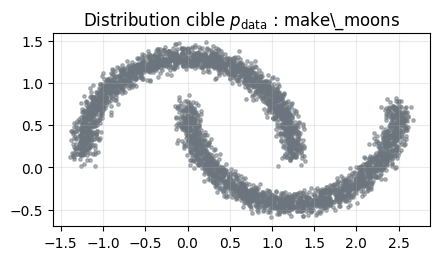

In [3]:
n_moons = 4000
moons_np, _ = make_moons(n_samples=n_moons, noise=0.06, random_state=SEED)
moons_np = moons_np * np.array([1.25, 1.15]) + np.array([0.0, 0.15])
moons = torch.tensor(moons_np, dtype=torch.float32, device=device)

plt.figure(figsize=(4.5, 4.2))
plt.scatter(moons_np[:, 0], moons_np[:, 1], s=6, alpha=0.5, color=COLOR_DATA)
plt.title(r"Distribution cible $p_{\mathrm{data}}$ : make\_moons")
plt.gca().set_aspect("equal")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### 2.1 Modèle : MLP prédisant la vitesse

Même architecture pour CFM et OT-CFM (pour une comparaison à capacité égale) : un MLP recevant
$(x_t, t, \sin(\pi t), \cos(\pi t)) \in \mathbb{R}^5$ et prédisant $v_\theta(t, x_t) \in \mathbb{R}^2$.


In [4]:
class FlowMLP(nn.Module):
    def __init__(self, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, t):
        if t.ndim == 1:
            t = t[:, None]
        feats = torch.cat([x, t, torch.sin(torch.pi * t), torch.cos(torch.pi * t)], dim=1)
        return self.net(feats)


def make_moons_batch(batch_size):
    x0 = torch.randn(batch_size, 2, device=device)
    idx = torch.randint(0, moons.shape[0], (batch_size,), device=device)
    x1 = moons[idx]
    return x0, x1


def train_moons_flow(use_ot, n_steps=4000, batch_size=512, lr=1e-3, log_every=500):
    torch.manual_seed(SEED if not use_ot else SEED + 1)
    model = FlowMLP().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    losses = []

    for step in tqdm(range(n_steps), desc=f"train {'OT-CFM' if use_ot else 'CFM'} (moons)"):
        x0, x1 = make_moons_batch(batch_size)
        if use_ot:
            col_ind = ot_pair_indices(x0, x1)
            x1 = x1[col_ind]

        t = torch.rand(batch_size, 1, device=device)
        alpha, beta, d_alpha, d_beta = linear_schedule(t)
        xt = alpha * x0 + beta * x1
        target_v = d_alpha * x0 + d_beta * x1

        pred_v = model(xt, t.squeeze(1))
        loss = F.mse_loss(pred_v, target_v)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        losses.append(loss.item())

        if (step + 1) % log_every == 0:
            print(f"  step {step + 1}/{n_steps} | loss = {np.mean(losses[-log_every:]):.4f}")

    return model, losses


In [5]:
model_cfm_moons, losses_cfm_moons = train_moons_flow(use_ot=False)
model_ot_moons, losses_ot_moons = train_moons_flow(use_ot=True)


train CFM (moons):   0%|          | 0/4000 [00:00<?, ?it/s]

  step 500/4000 | loss = 1.2793


  step 1000/4000 | loss = 1.2214


  step 1500/4000 | loss = 1.2089


  step 2000/4000 | loss = 1.1933


...

  step 2000/4000 | loss = 0.0193


  step 2500/4000 | loss = 0.0175


  step 3000/4000 | loss = 0.0166


  step 3500/4000 | loss = 0.0162


  step 4000/4000 | loss = 0.0161


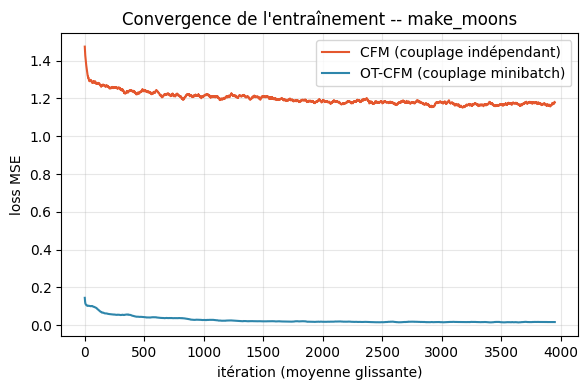

In [6]:
plt.figure(figsize=(6, 4))
window = 50
plt.plot(np.convolve(losses_cfm_moons, np.ones(window) / window, mode="valid"),
         color=COLOR_CFM, label="CFM (couplage indépendant)")
plt.plot(np.convolve(losses_ot_moons, np.ones(window) / window, mode="valid"),
         color=COLOR_OT, label="OT-CFM (couplage minibatch)")
plt.xlabel("itération (moyenne glissante)")
plt.ylabel("loss MSE")
plt.title("Convergence de l'entraînement -- make_moons")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "cfm_vs_otcfm_moons_loss.png", dpi=170, bbox_inches="tight")
plt.show()


### 2.2 Génération : échantillons et trajectoires

On génère par intégration Euler à $N=100$ pas, en partant des **mêmes** échantillons de bruit
$X_0$ pour les deux modèles, afin de comparer les trajectoires point par point.


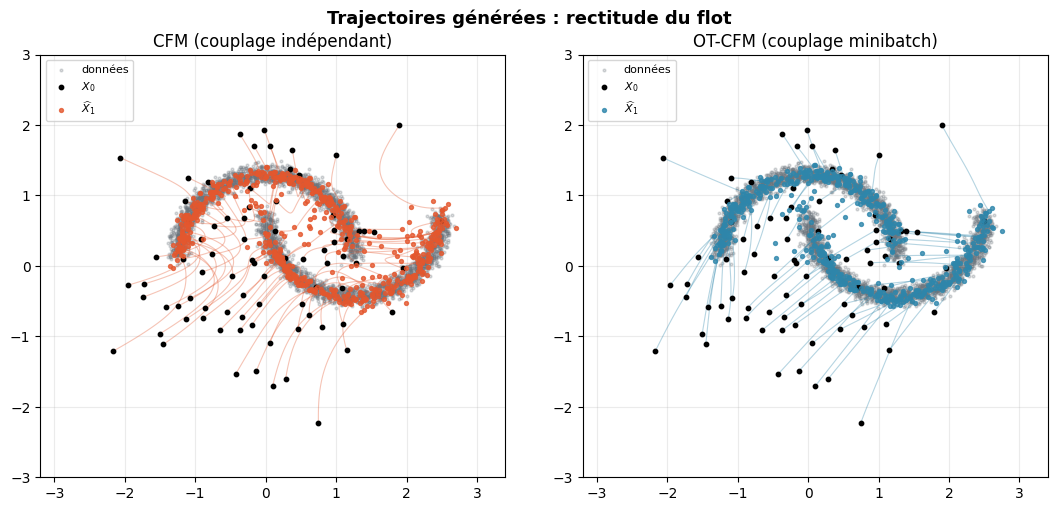

In [7]:
n_gen = 600
n_steps_gen = 100
x0_gen = torch.randn(n_gen, 2, device=device)

traj_cfm = euler_sample(model_cfm_moons, x0_gen, n_steps_gen).cpu().numpy()
traj_ot = euler_sample(model_ot_moons, x0_gen, n_steps_gen).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, traj, title, color in [
    (axes[0], traj_cfm, "CFM (couplage indépendant)", COLOR_CFM),
    (axes[1], traj_ot, "OT-CFM (couplage minibatch)", COLOR_OT),
]:
    ax.scatter(moons_np[:, 0], moons_np[:, 1], s=4, alpha=0.25, color=COLOR_DATA, label="données")
    n_show = 80
    for i in range(n_show):
        ax.plot(traj[:, i, 0], traj[:, i, 1], color=color, alpha=0.35, lw=0.8)
    ax.scatter(traj[0, :n_show, 0], traj[0, :n_show, 1], s=10, color="black", zorder=3, label=r"$X_0$")
    ax.scatter(traj[-1, :, 0], traj[-1, :, 1], s=8, color=color, zorder=3, alpha=0.8, label=r"$\widehat X_1$")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    ax.set_xlim(-3.2, 3.4)
    ax.set_ylim(-3.0, 3.0)
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Trajectoires générées : rectitude du flot", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES / "cfm_vs_otcfm_moons_trajectories.png", dpi=170, bbox_inches="tight")
plt.show()


## 3. Jeu de données images : MNIST

On passe maintenant en dimension $d = 1 \times 28 \times 28$. Le couplage OT en minibatch est
calculé dans l'espace pixel vectorisé $\mathbb{R}^{784}$ (coût quadratique), comme détaillé au
cours §9.5.


In [8]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, drop_last=True)
print("n images:", len(train_dataset))


n images: 60000


### 3.1 Modèle : U-Net (identique pour les deux méthodes)

In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(2, 32)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(64, 64)

        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)
        self.up2 = nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(32, 32)
        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x, t):
        t = t.view(-1, 1, 1, 1)
        t_map = t.expand(-1, 1, x.shape[2], x.shape[3])
        x = torch.cat([x, t_map], dim=1)

        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        b = self.bottleneck(p2)

        d1 = self.up1(b) + e2
        d1 = self.dec1(d1)
        d2 = self.up2(d1) + e1
        d2 = self.dec2(d2)
        return self.out(d2)


### 3.2 Boucle d'entraînement CFM / OT-CFM

Pour OT-CFM, l'appariement optimal est recalculé à chaque batch entre le bruit $x_0$ tiré et les
images $x_1$ du batch (coût quadratique en espace pixel, $\mathbb{R}^{784}$).


In [10]:
def train_unet_flow(use_ot, epochs=3, lr=1e-3):
    torch.manual_seed(SEED if not use_ot else SEED + 1)
    model = UNet().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        desc = f"epoch {epoch + 1}/{epochs} -- {'OT-CFM' if use_ot else 'CFM'} (MNIST)"
        for x1, _ in tqdm(train_loader, desc=desc):
            x1 = x1.to(device) * 2 - 1
            x0 = torch.randn_like(x1)

            if use_ot:
                col_ind = ot_pair_indices(x0, x1)
                x1 = x1[col_ind]

            t = torch.rand(x1.shape[0], 1, device=device)
            alpha, beta, d_alpha, d_beta = linear_schedule(t.view(-1, 1, 1, 1))
            xt = alpha * x0 + beta * x1
            target_v = d_alpha * x0 + d_beta * x1

            pred_v = model(xt, t.squeeze(1))
            loss = F.mse_loss(pred_v, target_v)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()

        avg = epoch_loss / len(train_loader)
        losses.append(avg)
        print(f"epoch {epoch + 1}/{epochs} | {'OT-CFM' if use_ot else 'CFM'} | loss = {avg:.5f}")

    return model, losses


In [11]:
model_cfm_mnist, losses_cfm_mnist = train_unet_flow(use_ot=False, epochs=3)


epoch 1/3 -- CFM (MNIST):   0%|          | 0/468 [00:00<?, ?it/s]

epoch 1/3 | CFM | loss = 0.44129


epoch 2/3 -- CFM (MNIST):   0%|          | 0/468 [00:00<?, ?it/s]

epoch 2/3 | CFM | loss = 0.25638


epoch 3/3 -- CFM (MNIST):   0%|          | 0/468 [00:00<?, ?it/s]

epoch 3/3 | CFM | loss = 0.23604


In [12]:
model_ot_mnist, losses_ot_mnist = train_unet_flow(use_ot=True, epochs=3)


epoch 1/3 -- OT-CFM (MNIST):   0%|          | 0/468 [00:00<?, ?it/s]

epoch 1/3 | OT-CFM | loss = 0.38856


epoch 2/3 -- OT-CFM (MNIST):   0%|          | 0/468 [00:00<?, ?it/s]

epoch 2/3 | OT-CFM | loss = 0.20296


epoch 3/3 -- OT-CFM (MNIST):   0%|          | 0/468 [00:00<?, ?it/s]

epoch 3/3 | OT-CFM | loss = 0.18327


### 3.3 Génération d'images

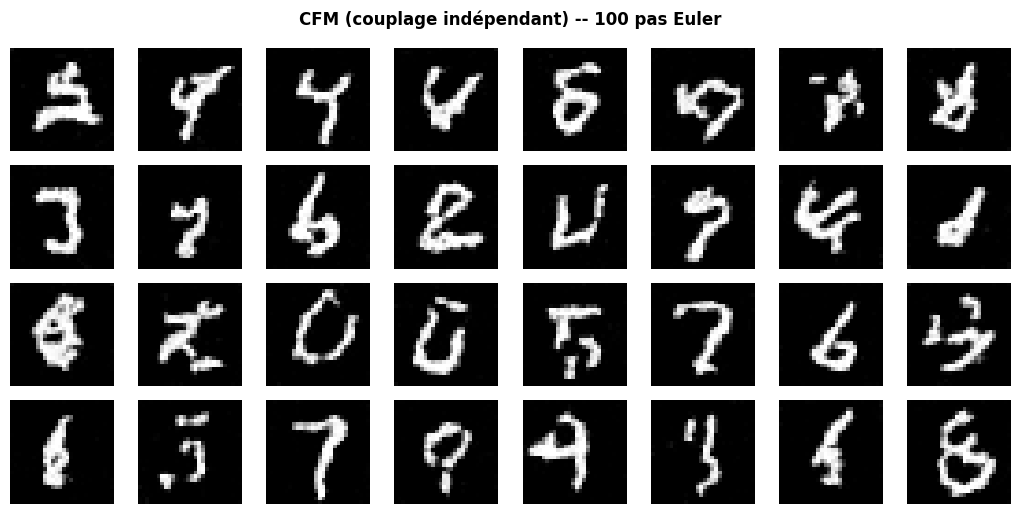

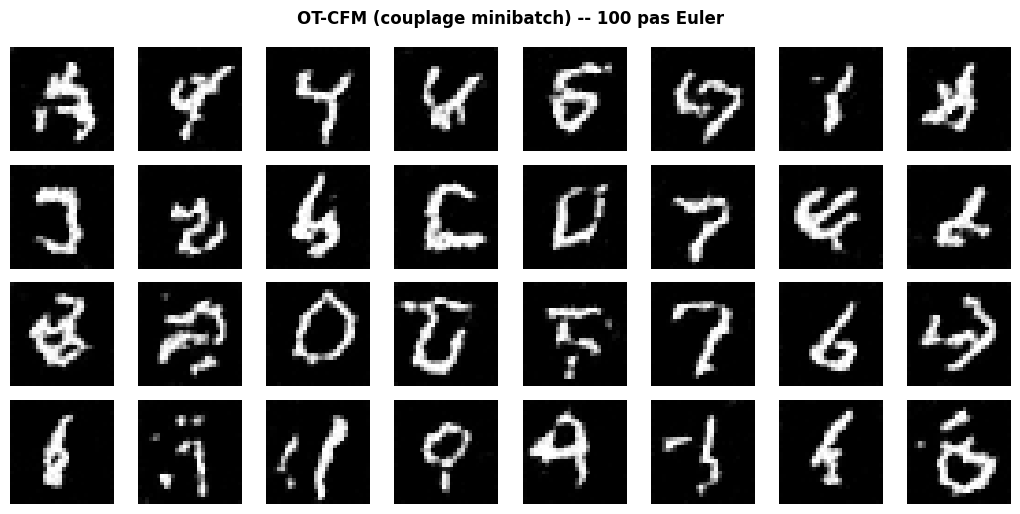

In [13]:
@torch.no_grad()
def sample_images(model, n_images, n_steps):
    model.eval()
    x = torch.randn(n_images, 1, 28, 28, device=device)
    dt = 1.0 / n_steps
    for k in range(n_steps):
        t = torch.full((n_images,), k / n_steps, device=device)
        x = x + dt * model(x, t)
    return ((x + 1) / 2).clamp(0, 1)


def show_grid(images, title, n=16, ncols=8):
    images = images[:n].detach().cpu()
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.3, nrows * 1.3))
    for i, ax in enumerate(axes.flat):
        if i < n:
            ax.imshow(images[i, 0], cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
    fig.suptitle(title, fontsize=12, fontweight="bold")
    fig.tight_layout()
    return fig


torch.manual_seed(123)
imgs_cfm = sample_images(model_cfm_mnist, 32, n_steps=100)
torch.manual_seed(123)
imgs_ot = sample_images(model_ot_mnist, 32, n_steps=100)

fig = show_grid(imgs_cfm, "CFM (couplage indépendant) -- 100 pas Euler", n=32)
fig.savefig(FIGURES / "cfm_mnist_samples.png", dpi=170, bbox_inches="tight")
plt.show()

fig = show_grid(imgs_ot, "OT-CFM (couplage minibatch) -- 100 pas Euler", n=32)
fig.savefig(FIGURES / "otcfm_mnist_samples.png", dpi=170, bbox_inches="tight")
plt.show()


## 4. Comparaison CFM vs OT-CFM

On compare maintenant quantitativement les deux méthodes selon trois axes :

1. **Courbure des trajectoires** (déviation par rapport à la droite $X_0 \to \widehat X_1$) ;
2. **Énergie cinétique moyenne** du chemin généré, $\int_0^1 \mathbb{E}[\|v_\theta(t,X_t)\|_2^2]\,dt$
   (cf. Théorème de Benamou-Brenier, cours §4.2) ;
3. **Qualité de génération en fonction du nombre de pas d'intégration (NFE)**, mesurée par la
   distance de Wasserstein empirique entre échantillons générés et données réelles sur
   `make_moons`.


### 4.1 Courbure des trajectoires (make_moons)

Pour une trajectoire parfaitement rectiligne, chaque point intermédiaire $X_t$ devrait être exactement
sur le segment $[X_0, \widehat X_1]$. On mesure, pour chaque trajectoire, l'écart quadratique moyen à
ce segment.


Erreur de rectitude moyenne -- CFM   : 0.2515
Erreur de rectitude moyenne -- OT-CFM: 0.0130


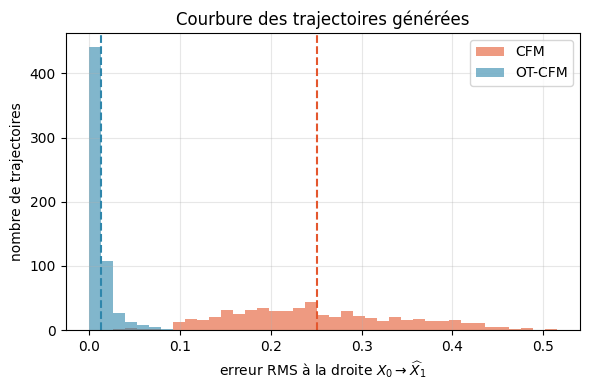

In [14]:
def straightness_error(traj):
    '''traj: (n_steps+1, n_samples, d). Renvoie l'erreur RMS à la droite X_0 -> X_1 par trajectoire.'''
    x0 = traj[0]
    x1 = traj[-1]
    n_steps = traj.shape[0] - 1
    errors = []
    for k in range(n_steps + 1):
        t = k / n_steps
        straight_point = (1 - t) * x0 + t * x1
        errors.append(((traj[k] - straight_point) ** 2).sum(axis=-1))
    errors = np.stack(errors, axis=0)  # (n_steps+1, n_samples)
    return np.sqrt(errors.mean(axis=0))  # (n_samples,)


straight_err_cfm = straightness_error(traj_cfm)
straight_err_ot = straightness_error(traj_ot)

print(f"Erreur de rectitude moyenne -- CFM   : {straight_err_cfm.mean():.4f}")
print(f"Erreur de rectitude moyenne -- OT-CFM: {straight_err_ot.mean():.4f}")

plt.figure(figsize=(6, 4))
bins = np.linspace(0, max(straight_err_cfm.max(), straight_err_ot.max()), 40)
plt.hist(straight_err_cfm, bins=bins, alpha=0.6, color=COLOR_CFM, label="CFM")
plt.hist(straight_err_ot, bins=bins, alpha=0.6, color=COLOR_OT, label="OT-CFM")
plt.axvline(straight_err_cfm.mean(), color=COLOR_CFM, ls="--", lw=1.5)
plt.axvline(straight_err_ot.mean(), color=COLOR_OT, ls="--", lw=1.5)
plt.xlabel("erreur RMS à la droite $X_0 \\to \\widehat X_1$")
plt.ylabel("nombre de trajectoires")
plt.title("Courbure des trajectoires générées")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / "cfm_vs_otcfm_straightness.png", dpi=170, bbox_inches="tight")
plt.show()


### 4.2 Énergie cinétique moyenne

On estime $\int_0^1 \mathbb{E}[\|v_\theta(t,X_t)\|_2^2]\,dt$ par une somme de Riemann le long des
trajectoires simulées : plus cette quantité est faible, plus le transport est proche de l'optimum du
Théorème de Benamou-Brenier (cours Théorème 4.1).


In [15]:
def kinetic_energy(model, x0, n_steps):
    model.eval()
    x = x0.clone()
    dt = 1.0 / n_steps
    energy = 0.0
    with torch.no_grad():
        for k in range(n_steps):
            t = torch.full((x.shape[0],), k / n_steps, device=x.device)
            v = model(x, t)
            energy += (v ** 2).sum(dim=-1).mean().item() * dt
            x = x + dt * v
    return energy


energy_cfm = kinetic_energy(model_cfm_moons, x0_gen, n_steps_gen)
energy_ot = kinetic_energy(model_ot_moons, x0_gen, n_steps_gen)
print(f"Énergie cinétique moyenne -- CFM   : {energy_cfm:.3f}")
print(f"Énergie cinétique moyenne -- OT-CFM: {energy_ot:.3f}")
print(f"Réduction relative : {100 * (1 - energy_ot / energy_cfm):.1f}%")


Énergie cinétique moyenne -- CFM   : 1.802
Énergie cinétique moyenne -- OT-CFM: 1.024
Réduction relative : 43.2%


### 4.3 Qualité de génération en fonction du nombre de pas (NFE)

On génère avec un nombre de pas $N$ croissant et on mesure la distance de Wasserstein empirique
$W_2$ (coût quadratique) entre les échantillons générés et la distribution cible, calculée
**exactement** entre deux nuages de même taille par affectation optimale (algorithme hongrois,
comme au §1.2 -- c'est le calcul de $W_2$ le plus direct entre mesures empiriques de même
cardinal). Une méthode aux trajectoires plus rectilignes doit atteindre une bonne qualité avec
**moins de pas** (moins d'évaluations du réseau, NFE = *number of function evaluations*).


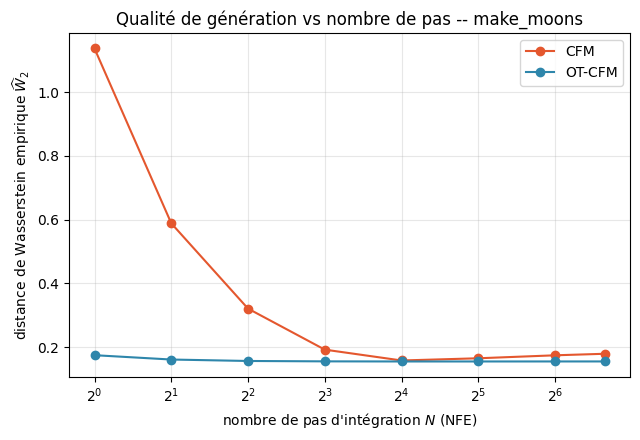

N steps : [1, 2, 4, 8, 16, 32, 64, 100]
W2 CFM   : ['1.137', '0.589', '0.321', '0.192', '0.158', '0.165', '0.174', '0.179']
W2 OT-CFM: ['0.175', '0.161', '0.157', '0.155', '0.155', '0.155', '0.155', '0.155']


In [16]:
def empirical_w2(samples, target, n_ref=300, seed=0):
    rng_local = np.random.default_rng(seed)
    idx_t = rng_local.choice(target.shape[0], size=min(n_ref, target.shape[0]), replace=False)
    idx_s = rng_local.choice(samples.shape[0], size=min(n_ref, samples.shape[0]), replace=False)
    s, tt = samples[idx_s], target[idx_t]
    cost = ((s[:, None, :] - tt[None, :, :]) ** 2).sum(axis=-1)
    row_ind, col_ind = linear_sum_assignment(cost)
    return math.sqrt(cost[row_ind, col_ind].mean())


n_steps_list = [1, 2, 4, 8, 16, 32, 64, 100]
w2_cfm, w2_ot = [], []
x0_eval = torch.randn(300, 2, device=device)

for n_steps in n_steps_list:
    gen_cfm = euler_sample(model_cfm_moons, x0_eval, n_steps)[-1].cpu().numpy()
    gen_ot = euler_sample(model_ot_moons, x0_eval, n_steps)[-1].cpu().numpy()
    w2_cfm.append(empirical_w2(gen_cfm, moons_np))
    w2_ot.append(empirical_w2(gen_ot, moons_np))

plt.figure(figsize=(6.5, 4.5))
plt.plot(n_steps_list, w2_cfm, "o-", color=COLOR_CFM, label="CFM")
plt.plot(n_steps_list, w2_ot, "o-", color=COLOR_OT, label="OT-CFM")
plt.xscale("log", base=2)
plt.xlabel("nombre de pas d'intégration $N$ (NFE)")
plt.ylabel(r"distance de Wasserstein empirique $\widehat W_2$")
plt.title("Qualité de génération vs nombre de pas -- make_moons")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(FIGURES / "cfm_vs_otcfm_nfe_quality.png", dpi=170, bbox_inches="tight")
plt.show()

print("N steps :", n_steps_list)
print("W2 CFM   :", [f"{v:.3f}" for v in w2_cfm])
print("W2 OT-CFM:", [f"{v:.3f}" for v in w2_ot])


### 4.4 Comparaison en un coup d'œil : figure de synthèse

On rassemble les résultats-clés (trajectoires, rectitude, NFE) dans une seule figure de synthèse,
utilisée aussi dans le cours.


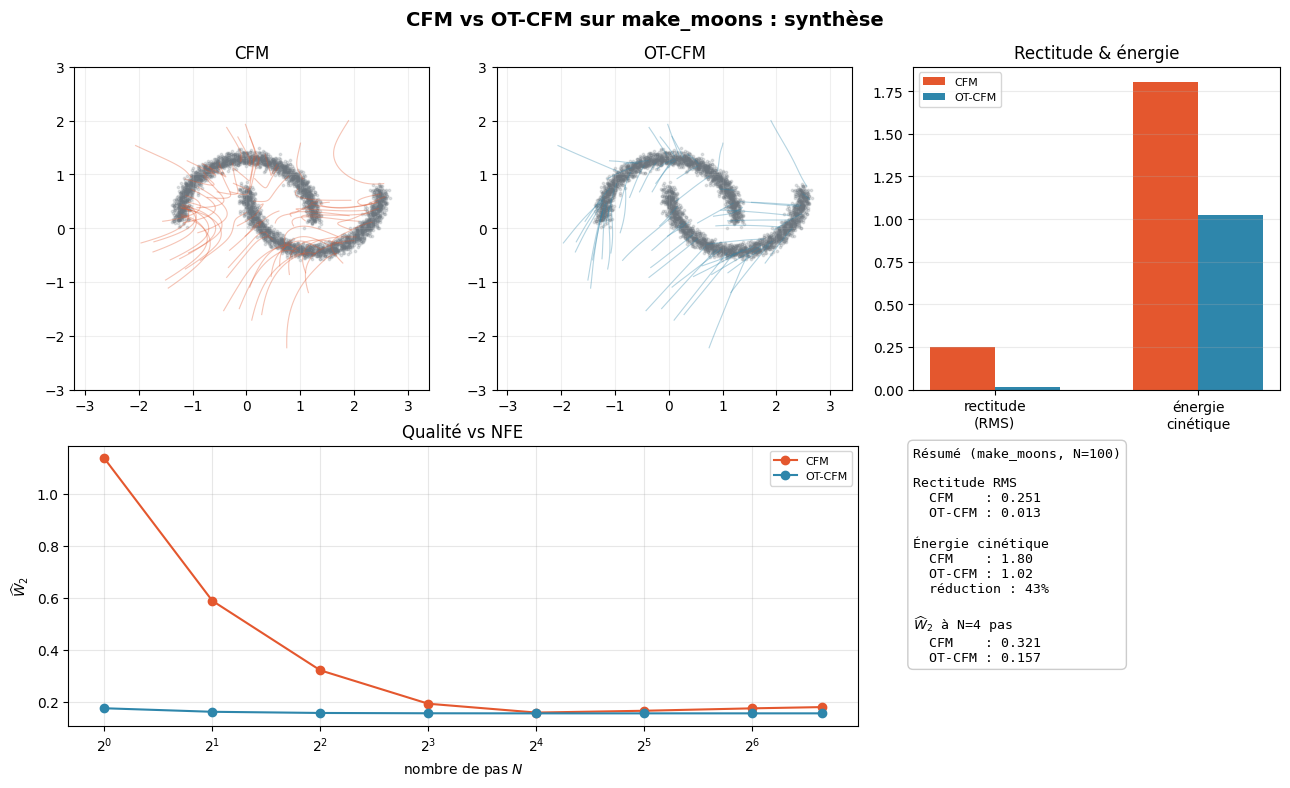

In [17]:
fig = plt.figure(figsize=(13, 8))
gs = GridSpec(2, 3, figure=fig, height_ratios=[1.15, 1])

# Row 1: trajectories
for col, (traj, title, color) in enumerate([
    (traj_cfm, "CFM", COLOR_CFM),
    (traj_ot, "OT-CFM", COLOR_OT),
]):
    ax = fig.add_subplot(gs[0, col])
    ax.scatter(moons_np[:, 0], moons_np[:, 1], s=3, alpha=0.2, color=COLOR_DATA)
    n_show = 60
    for i in range(n_show):
        ax.plot(traj[:, i, 0], traj[:, i, 1], color=color, alpha=0.35, lw=0.8)
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.set_xlim(-3.2, 3.4)
    ax.set_ylim(-3.0, 3.0)
    ax.grid(alpha=0.2)

ax_bar = fig.add_subplot(gs[0, 2])
metrics = ["rectitude\n(RMS)", "énergie\ncinétique"]
cfm_vals = [straight_err_cfm.mean(), energy_cfm]
ot_vals = [straight_err_ot.mean(), energy_ot]
x_pos = np.arange(len(metrics))
width = 0.32
ax_bar.bar(x_pos - width / 2, cfm_vals, width, color=COLOR_CFM, label="CFM")
ax_bar.bar(x_pos + width / 2, ot_vals, width, color=COLOR_OT, label="OT-CFM")
ax_bar.set_xticks(x_pos)
ax_bar.set_xticklabels(metrics)
ax_bar.set_title("Rectitude & énergie")
ax_bar.legend(fontsize=8)
ax_bar.grid(alpha=0.25, axis="y")

# Row 2: NFE quality (span 2 cols) + summary text
ax_nfe = fig.add_subplot(gs[1, 0:2])
ax_nfe.plot(n_steps_list, w2_cfm, "o-", color=COLOR_CFM, label="CFM")
ax_nfe.plot(n_steps_list, w2_ot, "o-", color=COLOR_OT, label="OT-CFM")
ax_nfe.set_xscale("log", base=2)
ax_nfe.set_xlabel("nombre de pas $N$")
ax_nfe.set_ylabel(r"$\widehat W_2$")
ax_nfe.set_title("Qualité vs NFE")
ax_nfe.legend(fontsize=8)
ax_nfe.grid(alpha=0.3, which="both")

ax_text = fig.add_subplot(gs[1, 2])
ax_text.axis("off")
summary = (
    f"Résumé (make_moons, N=100)\n\n"
    f"Rectitude RMS\n  CFM    : {straight_err_cfm.mean():.3f}\n  OT-CFM : {straight_err_ot.mean():.3f}\n\n"
    f"Énergie cinétique\n  CFM    : {energy_cfm:.2f}\n  OT-CFM : {energy_ot:.2f}\n"
    f"  réduction : {100 * (1 - energy_ot / energy_cfm):.0f}%\n\n"
    f"$\\widehat W_2$ à N=4 pas\n  CFM    : {w2_cfm[n_steps_list.index(4)]:.3f}\n"
    f"  OT-CFM : {w2_ot[n_steps_list.index(4)]:.3f}"
)
ax_text.text(0.0, 1.0, summary, va="top", ha="left", fontsize=9.5, family="monospace",
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="0.8"))

fig.suptitle("CFM vs OT-CFM sur make_moons : synthèse", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES / "cfm_vs_otcfm_summary.png", dpi=170, bbox_inches="tight")
plt.show()


### 4.5 Comparaison visuelle sur MNIST à peu de pas

Enfin, on illustre l'intérêt pratique sur les images : à très petit nombre de pas ($N$ faible), les
trajectoires courbes du CFM classique s'intègrent mal, alors que les trajectoires plus rectilignes de
l'OT-CFM se dégradent plus lentement.


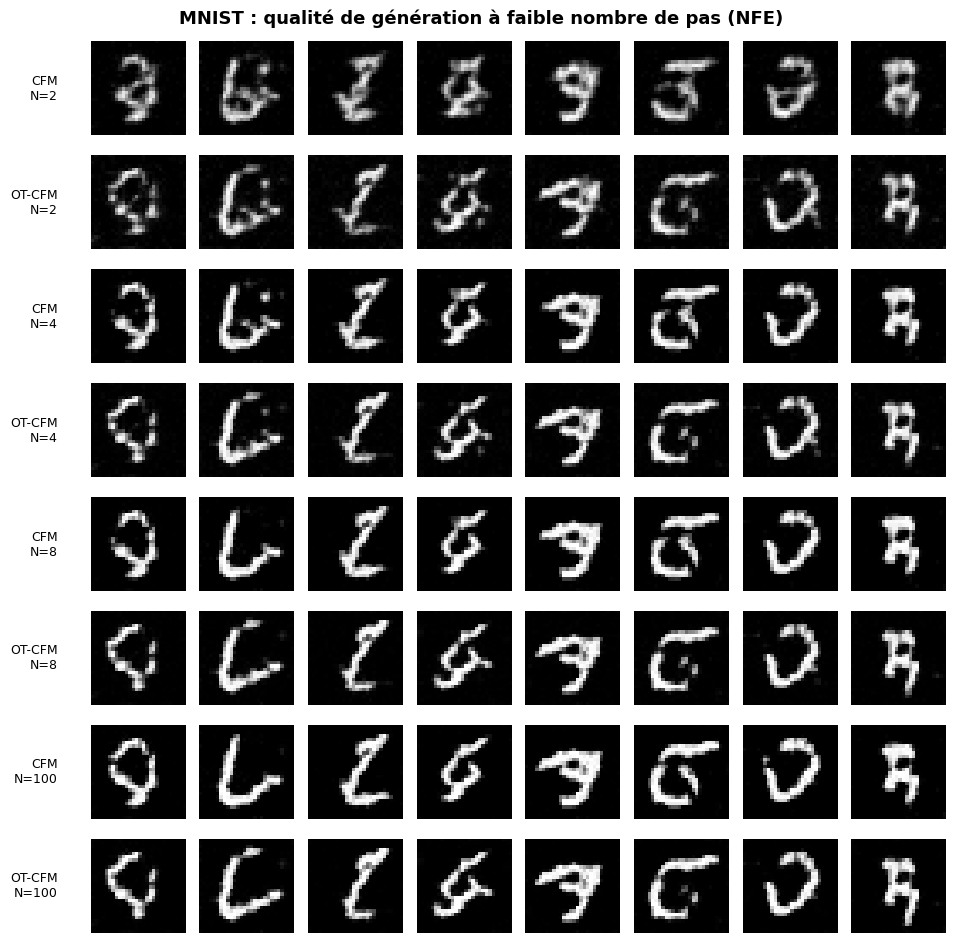

In [18]:
n_steps_compare = [2, 4, 8, 100]
n_show_mnist = 8

fig, axes = plt.subplots(2 * len(n_steps_compare), n_show_mnist,
                          figsize=(n_show_mnist * 1.2, 2 * len(n_steps_compare) * 1.2))

for row_block, n_steps in enumerate(n_steps_compare):
    torch.manual_seed(7)
    imgs_c = sample_images(model_cfm_mnist, n_show_mnist, n_steps)
    torch.manual_seed(7)
    imgs_o = sample_images(model_ot_mnist, n_show_mnist, n_steps)

    for col in range(n_show_mnist):
        ax_c = axes[2 * row_block, col]
        ax_c.imshow(imgs_c[col, 0].cpu(), cmap="gray", vmin=0, vmax=1)
        ax_c.axis("off")
        ax_o = axes[2 * row_block + 1, col]
        ax_o.imshow(imgs_o[col, 0].cpu(), cmap="gray", vmin=0, vmax=1)
        ax_o.axis("off")
        if col == 0:
            ax_c.text(-0.35, 0.5, f"CFM\nN={n_steps}", transform=ax_c.transAxes,
                      ha="right", va="center", fontsize=9)
            ax_o.text(-0.35, 0.5, f"OT-CFM\nN={n_steps}", transform=ax_o.transAxes,
                      ha="right", va="center", fontsize=9)

fig.suptitle("MNIST : qualité de génération à faible nombre de pas (NFE)", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES / "cfm_vs_otcfm_mnist_nfe.png", dpi=170, bbox_inches="tight")
plt.show()


## 5. Conclusion

| Critère | CFM (couplage indépendant) | OT-CFM (couplage minibatch) |
|---|---|---|
| Couplage $\pi$ | $p_0 \otimes p_1$ | transport optimal discret par batch |
| Coût entraînement | régression, *simulation-free* | régression + affectation $O(m^3)$ par batch (négligeable) |
| Rectitude des trajectoires | plus courbes | plus rectilignes (cf. §4.1) |
| Énergie cinétique | plus élevée | réduite (cf. §4.2, Benamou-Brenier) |
| Pas nécessaires (NFE) | $N$ grand pour bonne qualité | bonne qualité dès $N$ petit (cf. §4.3-4.5) |
| Minimiseur théorique | transporte $p_0 \to p_1$ (Thm. de marginalisation) | transporte $p_0 \to p_1$, **même minimiseur marginal** |

Les deux méthodes optimisent la **même famille de pertes** et convergent, en théorie, vers un champ
$v_\theta$ qui transporte correctement $p_0$ vers $p_{\mathrm{data}}$ (théorème de marginalisation,
cours Théorème 6.2). La différence n'est donc pas dans la *validité* du champ appris, mais dans sa
**forme géométrique** : le couplage OT en minibatch se rapproche du couplage de Monge (théorème de
Brenier), ce qui réduit l'énergie cinétique du transport (Benamou-Brenier) et donc la courbure des
trajectoires -- avec pour conséquence pratique directe un besoin en pas d'intégration bien moindre à
qualité de génération égale, aussi bien en 2D que sur des images.

Pour aller plus loin : *Optimal Flow Matching* (Kornilov *et al.*, 2024) pousse cette idée à son terme
en apprenant directement le potentiel de Brenier (paramétrisation convexe), ce qui donne un flot
rectiligne **exact** en un seul pas d'intégration (cours §8.2).
